<img src="Logo_UNSAM.png" width="180">

### Análisis y Procesamiento de Señales

# Trabajo Práctico N°1: Síntesis y operaciones de señales

### Paulina Benito

En el presente informe se realiza la síntesis de distintas señales en el dominio del tiempo, para luego estudiar su comportamiento en frecuencia a través de la Transformada de Fourier.

La primer señal analizada utilizaremos un senoide: 

In [53]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal

def funcion_sen( vmax , dc, k , ph, N,  fs) : 
    nn= np.arange(0,N)
    xx = dc + vmax * np.sin(k*(2*np.pi*fs/N)*nn/fs + ph)

    return (nn,xx)

Como se puede observar en la definición, el argumento del seno está en función de un parámetro k que representa un número entero que identifica un bin de frecuencia, muy útil al aplicar la Transformada Rápida de Fourier (FFT). Por otro lado, la separación de bins viene dada por: 
$$
\Delta f = \frac{f_s}{N}
$$
La frecuencia asociada a cada bin es $f_k = k\Delta f$. Por lo tanto, al elegir un valor de k, se selecciona una frecuencia específica dentro de la grilla de frecuencias de la DFT. Finalmente, n representa el índice de muestra, el N la cantidad total de muestras, fs la frecuencia de muestro, Vmáx la amplitud de la señal, dc la componente de contunua y ph la fase inicial.

A continuación se comenzarán las simulaciones teniendo en cuenta que N estará siempre fijo en 1000 muestras. 

#### 1. Primera simulación: señal de 2 kHz que tenga al menos 10 puntos por período.

Considerando que la frecuencia de muestreo $f_s$ representa las muestras por segundos y la frecuencia de la señal $f_0$ indica cuántos períodos por segundos tiene, como se necesitan al menos 10 muestras por período, despejo la $f_s$: 
$$
\frac{f_s}{f_0}\geq 10
$$
quedando $f_s \geq 10*f_0$. Como por enunciado exige una $f_0= 2kHz= 2000Hz$, obtengo una frecuencia de muestreo igual a $f_s= 20kHz=20000Hz$.
Como ya tenemos ambas frecuencias solo queda determinar el valor para k. Sabiendo que la frecuencia de la señal queda definida como $ f_0= k*\Delta f = k*\frac {f_s}{N}$ obtengo que $k= \frac {f_0*N}{f_s}= 100$. 

Con estos cálculos realizados ya queda todo definido para simular la función. 

2.0


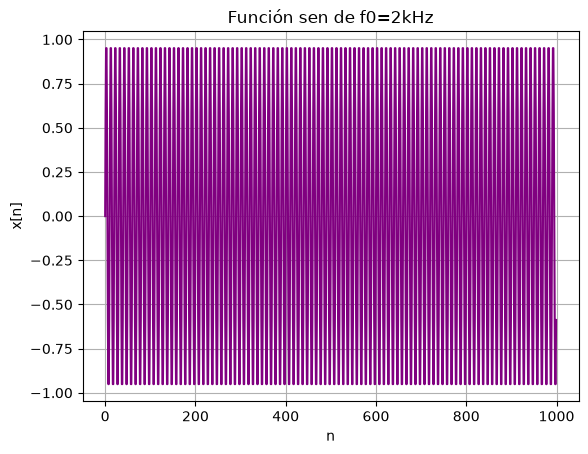

In [54]:
N=1000
fs=20000 #Hz
k=100
ph=0
dc=0
vmax=1
nn= np.arange(0,N)

f0_kHz = (k * fs / N) / 1000
print(f0_kHz)  #controlo que me quede la frecuencia correcta.

nn,xx1=funcion_sen(vmax, dc, k, ph, N, fs)

plt.figure()
plt.plot(nn,xx1, color="purple")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Función sen de f0=2kHz")
plt.grid()
plt.show()

El gráfico se observa denso porque, al impoener 10 puntos por períodos y 1000 muestras, se representan 100 períodos completos de la señal. 

Una vez generada la señal en el dominio temporal, se aplica la FFT para estudiar el contenido en frecuencia. Con la FFT se obtiene $X[K]$, donde cada $k$ corresponde a un bin de frecuencia como se explicó anteriormente. Para facilitar la interpretación se grafica el módulo $|X[k]|$, ya que permite representar en qué frecuencias se concentra la señal y su magnitud en cada componente espectral. 

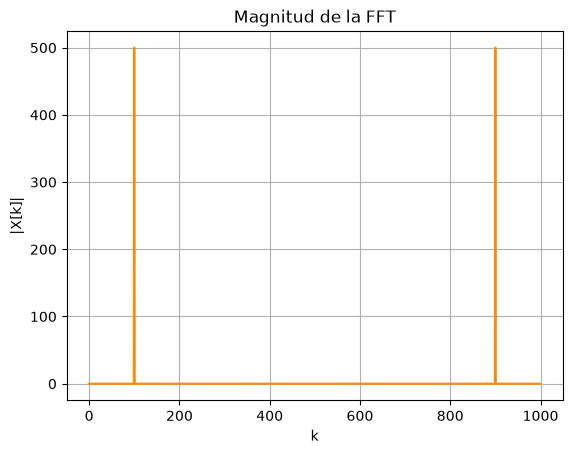

In [94]:
X = np.fft.fft(xx1)
mag = np.abs(X) 
plt.figure()
plt.plot(mag, color="darkorange")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.title("Magnitud de la FFT")
plt.grid()
plt.show()


Del gráfico se pueden observar dos picos simétricos en $k=100$ y $k=900$. Como la señal es real, no compleja, al aplicar la FFT en el espectro aparece una **simetría conjugada**.Por ende, el primero corresponde a la componente positiva de la señal y el segundo a su componente conjugada asociada a la frecuencia negativa, ya que $N-k=1000-100=900$. 
Además, como la señal tiene amplitud 1 y la FFT no fue normalizada (no se dividió por la cantidad de muestras), entonces cada pico tiene una magnitud aproximada de $\frac {A*N}{2}= 500$ que coincide con el gráfico. 

#### 2. Segunda simulación: misma señal con 2 W de potencia media y desfasada en π/2.

Para la siguiente simulación se utiliza la misma señal que en la anterior pero se modifican algunos parámetros. Sabiendo que para una senoide con amplitud A, la potencia queda definida como: 
$$
P= \frac {A^2}{2}
$$
Para cumplir el requisito de potencia media de 2W, despejo el valor de la amplitud  $A^2=4 $ quedando $A=2$.
Modifico los parámetros de amplitud y fase y grafico. 

<function matplotlib.pyplot.show(close=None, block=None)>

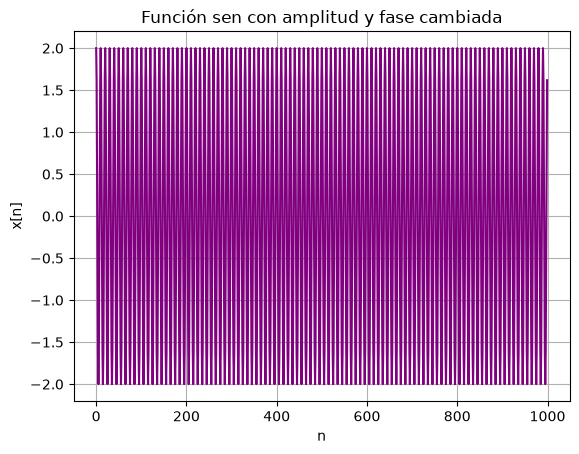

In [95]:
N=1000
fs=20000
k=100
ph=np.pi/2
dc=0
vmax=2
nn= np.arange(0,N)

nn,xx2=funcion_sen(vmax, dc, k, ph, N, fs)

plt.figure()
plt.plot(nn,xx2, color="purple")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Función sen con amplitud y fase cambiada")
plt.grid()
plt.show 

El gráfico muestra que la señal conserva la misma frecuencia que en el caso anterior, pero presenta una amplitud de 2 V para cumplir con la potencia media requerida y un desfase de π/2. Debido a la gran cantidad de períodos representados, el efecto de la fase no se distingue claramente en la gráfica completa. A continuación se grafica con zoom en las primeras 50 muestras para poder observar este efecto. 

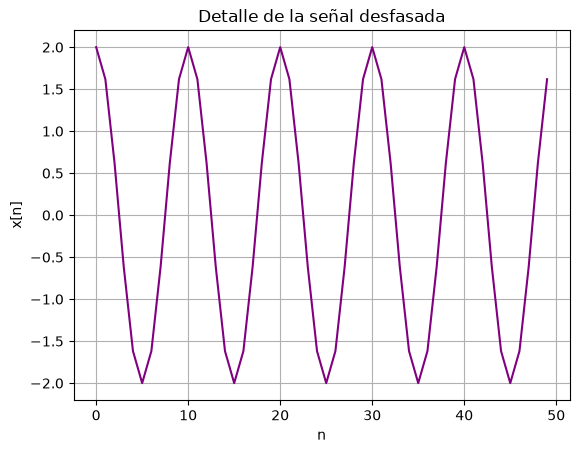

In [96]:
plt.figure()
plt.plot(nn[:50], xx2[:50], color="purple")
plt.xlabel("n")
plt.ylabel("x[n]")
plt.title("Detalle de la señal desfasada")
plt.grid()
plt.show()

Con este zoom se ve perfectamente el desfasaje a π/2, que junto a la nueva amplitud, hace que la señal empiece en su valor máximo positivo en vez de empezar en 0.  

Como ya se tiene la señal en dominio del tiempo graficada ahora evaluamos su FFT. 

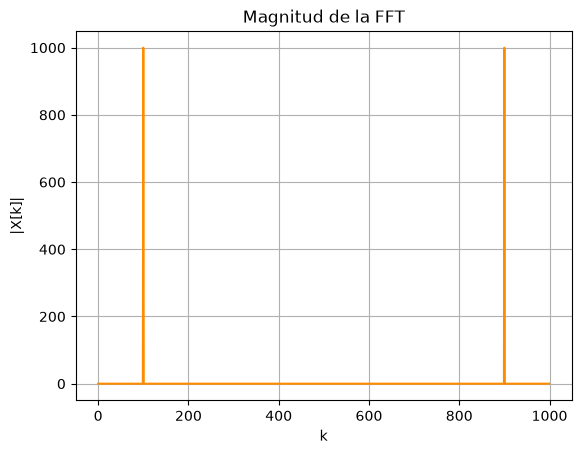

In [97]:
X2 = np.fft.fft(xx2)
mag2 = np.abs(X2) 
plt.figure()
plt.plot(mag2, color="darkorange")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.title("Magnitud de la FFT")
plt.grid()
plt.show()

Al comparar este gráfico de $|X[k]|$ con el de la simulación anterior se observa que el pico llega a 1000 en vez de 500. Esto se debe a que al dumplicar el valor de la amplitud, se duplica el valor del pico: $\frac {A*N}{2}= \frac {2*1000}{2}= 1000$. Como la frecuencia es la misma, se mantienen las componentes de k. El desfase no modifica el módulo del espectro, solo la fase, por eso no afecta al gráfico. 

#### 3. Tercer simulación: una secuencia aleatoria de ruido normalmente distribuido con DC (valor medio) 0V y varianza 0.1 W.

Para este caso, ya no se genera una señal determinística (que está completamente definida) como en los casos anteriores, sino que una secuencia aleatoria de ruido con distribución normal. Como la consigna establece, se tomará un valor medio de 0V, por lo que las muestras quedan definidas alrededor del cero, y una varianza de 0.1W lo que determina la dispersión del ruido. 

En la distribución normal, la función utiliza la desviación estándar $\sigma$, la cual la obtengo a partir de la varianza: 
$$
\sigma^2= 0.1
$$
entonces: 
$$
\sigma= \sqrt{0.1}= 0.3166
$$

In [98]:
def ruido_general(media, varianza, N):
    desvio= np.sqrt(varianza)
    ruido= np.random.normal(media, desvio, N)
    return ruido

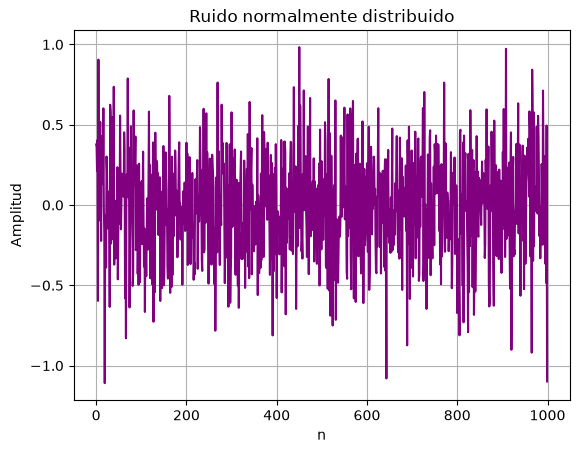

In [99]:
N=1000
varianza= 0.1
media= 0
ruido= ruido_general(media, varianza, N)
n = np.arange(N)

plt.figure()
plt.plot(n, ruido, color="purple")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Ruido normalmente distribuido")
plt.grid()
plt.show()

Una vez obtenido el ruido, se evalúa su FFT.

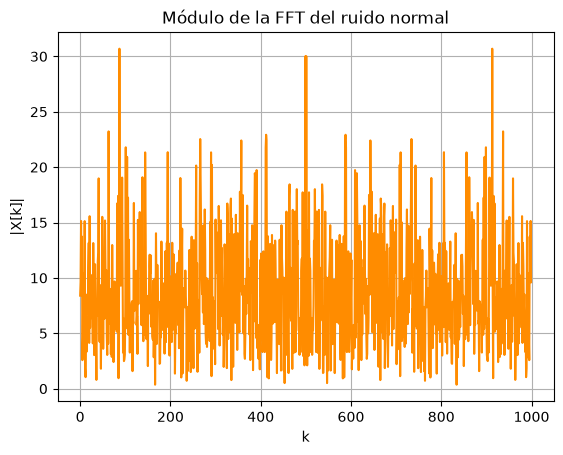

In [100]:
X_ruido = np.fft.fft(ruido)
mag_ruido = np.abs(X_ruido)
k = np.arange(N)

plt.figure()
plt.plot(k, mag_ruido, color="darkorange")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.title("Módulo de la FFT del ruido normal")
plt.grid()
plt.show()

A diferencia de una senoidal, que aparecen dos picos en su FFT debido a que su energía estaba concentrada en una frecuencia, con el ruido normal la energía está distribuída entre muchos bins sin tener una frecuencia dominante. 

#### 4. Cuarta simulación: una secuencia aleatoria de ruido uniformemente distribuido con DC (valor medio) 0V y varianza 0.1 W. 

En esta simulación se generará una secuencia aleatoria de ruido con distribución uniforme, manteniendo las mismas condiciones de media nula y varianza de 0,1 W utilizadas en el caso anterior. A diferencia del ruido normal, en este caso las muestras presentan igual densidad de probabilidad dentro de un intervalo determinado.
La media que sigue una distribución uniforme queda definida como:
$$
\mu = \frac{a+b}{2}
$$
y la varianza: 
$$
\sigma^2 = \frac{(b-a)^2}{12}
$$
Como se quiere que el ruido quede centrado en 0, es decir, que $\mu = 0$ se toma $a=-A$  y $b=A$. Entonces ahora para obtener el valor de $A$ se despeja desde la varianza: 
$$
\sigma^2 = \frac{(A-(-A))^2}{12}
= \frac{A^2}{3} 
$$
A partir de estos cálculos obtengo que $A = \sqrt{3\sigma^2}$. Este parámetro $A≈0.54772$ será el semiancho de la distribución uniforme. 

In [101]:
def ruido_uniforme(media, varianza, N):  #lo escribí de forma general
    A = np.sqrt(3 * varianza)
    a= media -A                                    
    b= media +A
    ruido_uniforme = np.random.uniform(a, b, N)
    return ruido_uniforme

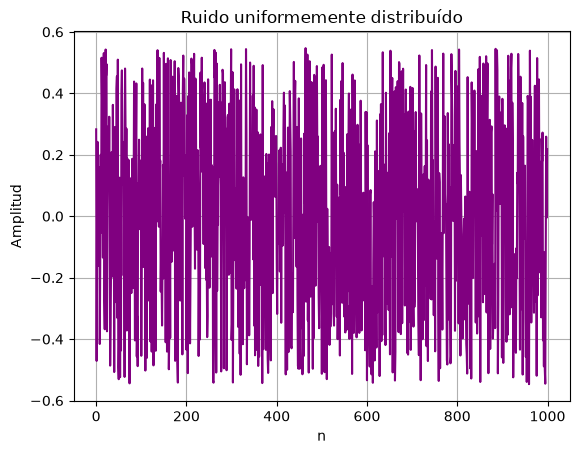

In [102]:
N=1000
media= 0
varianza= 0.1
ruido2= ruido_uniforme(media, varianza, N)
n = np.arange(N)

plt.figure()
plt.plot(n, ruido2, color="purple")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Ruido uniformemente distribuído")
plt.grid()
plt.show()

#Grafico el histograma para comprobar que es una distribución uniforme


Con respecto al gráfico del ruido se lo puede observar distribuído alrededor del 0 con los límites corresponidentes a aproximademente $+/-A$.

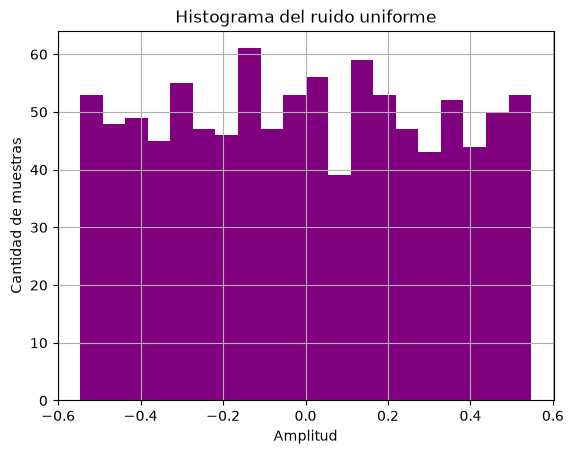

In [103]:
plt.figure()
plt.hist(ruido2, bins=20, color="purple")
plt.xlabel("Amplitud")
plt.ylabel("Cantidad de muestras")
plt.title("Histograma del ruido uniforme")
plt.grid()
plt.show()

Al graficar el histograma del ruido, se oberva mejor el comportamiento esperado para una distribución uniforme, sin una concentración predominante alrededor de un valor específico. Las pequeñas diferencias entre las alturas de las barras se deben al carácter aleatorio y al número finito de muestras utilizadas.

A continuación se aplicará la FFT. 

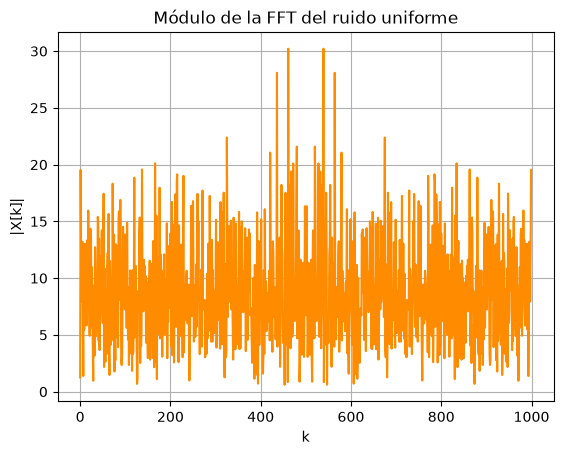

In [104]:
X_ruidouniforme= np.fft.fft(ruido2)
mag_ruidouniforme= np.abs(X_ruidouniforme)
k = np.arange(N)

plt.figure()
plt.plot(k, mag_ruidouniforme, color="darkorange")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.title("Módulo de la FFT del ruido uniforme")
plt.grid()
plt.show()

Al igual que en el caso del ruido normalmente distribuido, el módulo de la FFT presenta componentes repartidas a lo largo de todo el espectro, sin una frecuencia dominante. Esto es coherente con el comportamiento aleatorio del ruido.

La diferencia importante entre ruido normal y uniforme está más en cómo se distribuyen las amplitudes en el dominio temporal que en la forma general del módulo de la FFT.

#### 5. Quinta simulación: un pulso rectangular de la misma frecuencia, 1 W de potencia y ciclo de actividad del 50%

En esta simulación se genera una señal cuadrada con la misma frecuencia utilizada en casos anteriores, es decir, $f_0= 2kHz$. Como se mantienen $N=1000$ y $f_s= 20000Hz$, el parámetro k sigue siendo $k=100$.

Para generar la señal se utiliza scipy.signal.square, que permite definir una onda cuadrada a partir de su fase y del ciclo de actividad. En este caso se toma un duty=0.5, lo que significa que la señal permanece el 50% del período en el nivel alto y el 50% en el nivel bajo.
La señal generada toma valores entre $+/-1$ debido a que una señal simétrica, la amplitud queda dada por la potencia media: 
$$
P= A^2= 1
$$
Con estos parámetros definidos ya puedo declarar mi función. 

In [105]:
def funcion_cuadrada(N,k, duty):
    n= np.arange(N)
    x_cuadrada = signal.square(2*np.pi*(k/N)*n,duty=duty)
    return x_cuadrada

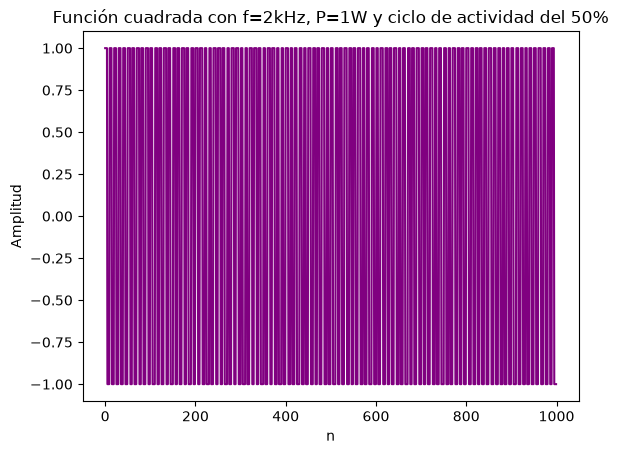

In [106]:
N=1000
k=100
duty=0.5
xx_cuadrada= funcion_cuadrada(N,k, duty)
n = np.arange(N)

plt.figure()
plt.plot(n, xx_cuadrada, color="purple")
plt.title("Función cuadrada con f=2kHz, P=1W y ciclo de actividad del 50%")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.show()


Como ocurrió antes con las senoides, el gráfico se observa muy denso debido a que dentro de las 1000 muestras se representan una gran cantidad de períodos. Para ver mejor la forma cuadrada y el ciclo de actividad, grafico las primeras 50 muestras: 

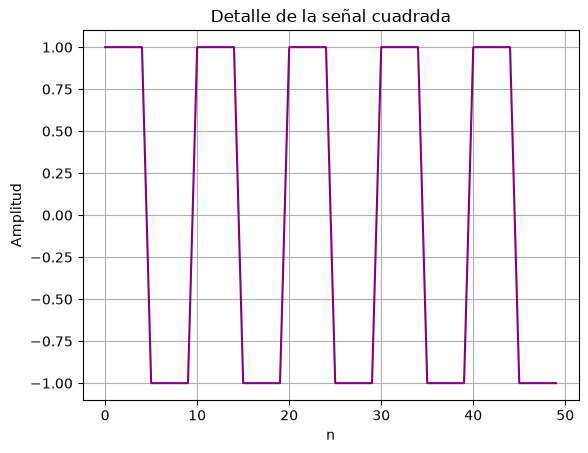

In [107]:
plt.figure()
plt.plot(n[:50], xx_cuadrada[:50], color="purple")
plt.xlabel("n")
plt.ylabel("Amplitud")
plt.title("Detalle de la señal cuadrada")
plt.grid()
plt.show()

Con este zoom podemos observar mejor el comportamiento de la señal. Se ve claramente que la amplitud oscila entre $+/-1$ y que el ciclo de actividad corresponde a mitad en la amplitud $+1$ y la otra mittad en $-1$.

Lo siguiente es aplicar la FFT. 

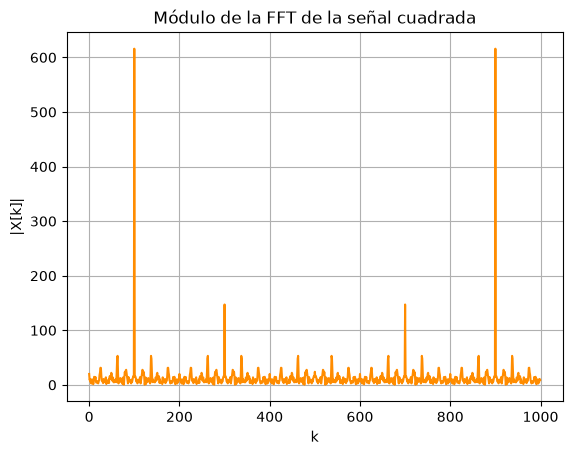

In [108]:
X_cuadrada= np.fft.fft(xx_cuadrada)
mag_Xcuadrada= np.abs(X_cuadrada)
k = np.arange(N)

plt.figure()
plt.plot(k, mag_Xcuadrada, color="darkorange")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.title("Módulo de la FFT de la señal cuadrada")
plt.grid()
plt.show()


El módulo de la FFT de la señal cuadrada presenta una componente fundamental en $k=100$ y su correspondiente componente simétrica en $k=900$. A diferencia de la señal senoidal, cuya FFT concentra prácticamente toda la energía en la frecuencia fundamental, la señal cuadrada contiene además varios armónicos. En particular, para un ciclo de actividad del 50%, aparecen principalmente armónicos impares de la frecuencia fundamental, como $3f_0$, $5f_0$, etc., y su magnitud va disminuyendo a medida que aumenta el orden. Esto explica por qué la forma cuadrada necesita varias componentes de frecuencia para poder representar sus cambios bruscos de nivel.

#### 6. Sexta simulación: implementar otra señal del paquete spicy.signal

Para esta simulación voy a implentar la señal "chirp" del paquete spicy.signal. A diferencia de las señales analizadas anteriormente, el chirp presenta una frecuencia que varía a lo largo del tiempo, por ende conviene trabajar con el vector $t$, ya que permite identificar el instante correspondiente a cada muestra y representar correctamente cómo cambia la frecuencia a lo largo del tiempo. En este caso se utilizará un barrido lineal entre una frecuencia inicial ($100 Hz$) y una frecuencia final ($2000Hz$), con el objetivo de observar tanto su evolución temporal como su contenido frecuencial.

In [109]:
def xx_chirp(N, fs,f0, f1):
    T = N / fs
    t = np.arange(N) / fs
    x_chirp = signal.chirp(t, f0=f0,f1=f1,t1=T, method="linear")
    return t, x_chirp

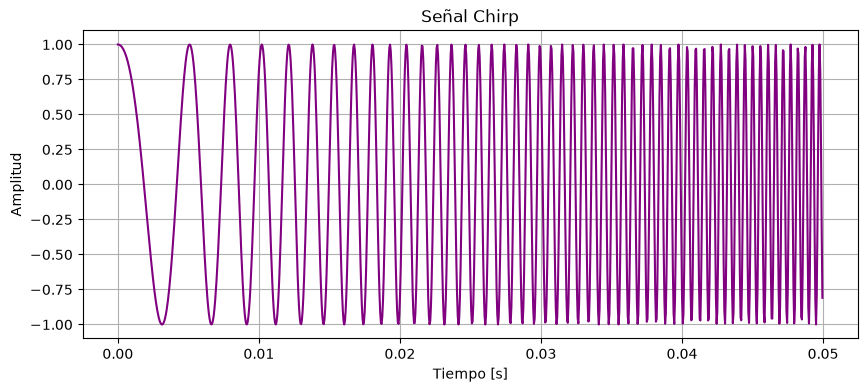

In [110]:
N=1000
fs=20000
f0=100
f1=2000
t, x_chirp= xx_chirp(N, fs,f0, f1)


plt.figure(figsize=(10,4))

plt.plot(t, x_chirp, color="purple")

plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal Chirp")

plt.grid()
plt.show()

En el gráfico se observa que al comienzo las oscilaciones están más separadas y, a medida que avanza el tiempo, se van acercando entre sí. Esto ocurre porque la frecuencia de la señal chirp aumenta progresivamente y el período es inversamente proporcional a la frecuencia, es decir, $T=\frac{1}{f}$. Por lo tanto, cuando la frecuencia es baja el período es mayor, mientras que al aumentar la frecuencia el período disminuye y entran más ciclos en un mismo intervalo de tiempo.

A continución se aplica la FFT. 

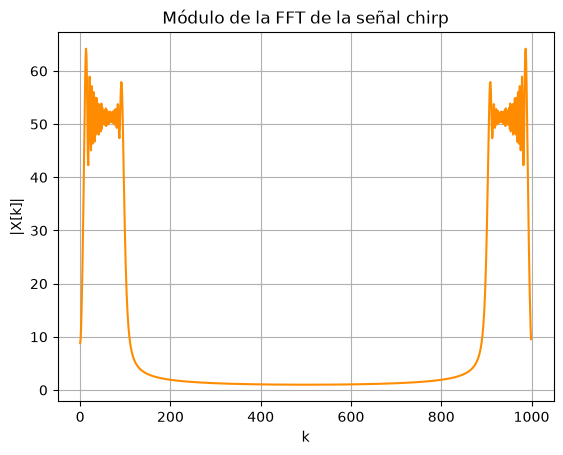

In [111]:
X_chirp= np.fft.fft(x_chirp)
mag_Xchirp= np.abs(X_chirp)

plt.figure()
plt.plot(k, mag_Xchirp, color="darkorange")
plt.xlabel("k")
plt.ylabel("|X[k]|")
plt.title("Módulo de la FFT de la señal chirp")
plt.grid()
plt.show()


A diferencia de una señal senoidal, el chirp no presenta una única componente frecuencial, ya que su frecuencia varía a lo largo del tiempo. Por este motivo, el módulo de la FFT muestra energía distribuida en un intervalo de bins correspondiente al rango de frecuencias recorrido por la señal. Además, al tratarse de una señal real, aparece la correspondiente simetría entre las componentes de frecuencia positiva y negativa.

#### 7. Teorema de Parseval  

El Teorema de Parseval establece que la energía de una señal se conserva al pasar del dominio temporal al dominio frecuencial.

$$
\sum_{n=0}^{N-1}|x[n]|^2
=
\frac{1}{N}\sum_{k=0}^{N-1}|X[k]|^2
$$
Por lo tanto, la potencia media puede calcularse tanto a partir de las muestras $x[n]$ como a partir de su transformada $X[k]$. 
$$
P=\frac{1}{N}\sum_{n=0}^{N-1}|x[n]|^2
$$
$$
P=\frac{1}{N^2}\sum_{k=0}^{N-1}|X[k]|^2
$$
A continuación, se utilizará esta relación para verificar que la potencia obtenida mediante la FFT coincide con la calculada directamente en el dominio temporal sobre la señal cuadrada utilizada en la simulacón anterior.

In [113]:
P_tiempo = np.mean(np.abs(xx_cuadrada)**2)
X_cuadrada = np.fft.fft(xx_cuadrada)
P_fft = np.sum(np.abs(X_cuadrada)**2) / N**2

print("Potencia calculada en el tiempo:", P_tiempo)
print("Potencia calculada mediante FFT:", P_fft)

Potencia calculada en el tiempo: 1.0
Potencia calculada mediante FFT: 1.0000000000000002


Para comprobar el Teorema de Parseval se calcula primero la potencia media de la señal directamente en el dominio temporal, promediando el cuadrado de sus muestras. Luego se obtiene la FFT de la señal y se calcula nuevamente la potencia a partir de la suma del cuadrado del módulo de sus componentes frecuenciales, aplicando la normalización correspondiente. Como se obtiene una potencia de $1W$ en ambos casos, salvo una diferencia numérica despreciable, se verifica que la potencia de la señal se conserva al pasar del dominio temporal al dominio frecuencial.

### Conclusión 

Este trabajo permitió ver de manera práctica cómo se comportan distintos tipos de señales y cómo cambia su representación al analizarlas mediante la FFT. A partir de las simulaciones se pudieron comparar señales senoidales, ruidos, una señal cuadrada y un chirp, relacionando lo observado en el tiempo con su contenido en frecuencia. También se verificó, mediante Parseval, que la potencia puede calcularse de forma equivalente en ambos dominios.